### Separate testing of the combustion implementation

In [1]:

##############################################################################################################
# Imports
##############################################################################################################

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.integrate import solve_ivp, cumulative_trapezoid


In [2]:
##############################################################################################################
# Conservation of mass & energy
##############################################################################################################

def internal_energy(T, F):
    
    """
    Compute specific internal energy u(T, F) and its derivative w.r.t T.
    
    Parameters
    ----------
    T : float or np.array
        Gas temperature [K]
    F : float or np.array
        Fuel-air equivalence ratio [-]
    
    Returns
    -------
    u : float or np.array
        Specific internal energy [J/kg]
    du_dT : float or np.array
        Derivative of u w.r.t temperature [J/(kg K)]
    """
    
    # Example: Cv depends weakly on F
    Cv = 718.0 * (1 + 0.01 * F)  # J/kg·K, slight dependence on fuel fraction
    u = Cv * T
    du_dT = Cv
    
    return u, du_dT


def gas_constant(F, f_s):
    
    """
    Compute gas constant R as a function of equivalence ratio F.
    
    Parameters
    ----------
    F : float or np.array
        Fuel-air equivalence ratio [-]
    f_s : float
        Stoichiometric fuel-air ratio [-]
    
    Returns
    -------
    R : float or np.array
        Gas constant [kJ/(kg·K)] or [kPa·m³/(kg·K)] depending on units
    """
    
    R = (0.278 + 0.02 * F) / (1 + f_s * F)
    
    return R



# Total mass = air mass + fuel mass
def total_mass(m_air, m_bf):
    
    """
    Compute total mass in the control volume (Eq. 41)
    
    Parameters
    ----------
    m_air : float
        Mass of air [kg]
    m_bf : float
        Burned fuel mass [kg]
    
    Returns
    -------
    m : float
        Total mass [kg]
    """
    
    return m_air + m_bf



# Compute fuel-air equivalence ratio F (Eq. 42)
def fuel_air_equivalence_ratio(f, f_s):
    
    """
    Compute fuel-air equivalence ratio (Eq. 42)
    
    Parameters
    ----------
    f : float
        Fuel-to-air mass ratio [-]
    f_s : float
        Stoichiometric fuel-air ratio [-]
    
    Returns
    -------
    F : float
        Equivalence ratio [-]
    """
    
    return f / f_s


def equivalence_ratio_derivative(F, m_bf_dot, m_dot, f_s, m):
    
    """
    Compute derivative of equivalence ratio F' (Eq. 43)
    
    Parameters
    ----------
    F : float
        Fuel-air equivalence ratio [-]
    m_bf_dot : float
        Burned fuel mass rate [kg/s]
    m_dot : float
        Total mass derivative [kg/s]
    f_s : float
        Stoichiometric fuel-air ratio [-]
    m : float
        Total mass of control volume [kg]
        
    Returns
    -------
    F_dot : float
        Derivative of equivalence ratio
    """
    
    numerator = (1 + f_s * F)/f_s * m_bf_dot - F * m_dot
    F_dot = (1 + f_s * F)/m * numerator
    
    return F_dot

In [3]:
##############################################################################################################
# Valve mass flow
##############################################################################################################

def valve_mass_flow(Cd, Av, Pu, Pd, T_u, gamma, R):
    
    """
    Compute mass flow rate through a valve.

    Parameters
    ----------
    Cd : float
        Discharge coefficient [-]
    Av : float
        Valve area [m²]
    Pu : float
        Upstream pressure [Pa]
    Pd : float
        Downstream pressure [Pa]
    T_u : float
        Upstream temperature [K]
    gamma : float
        Specific heat ratio (Cp/Cv) [-]
    R : float
        Gas constant [J/(kg K)]
    
    Returns
    -------
    m_dot : float
        Mass flow rate [kg/s]
    """
    
    # Critical pressure ratio for sonic flow
    PR_critical = (2/(gamma+1))**(gamma/(gamma-1))
    
    if Pd/Pu <= PR_critical:  # Choked flow
        m_dot = Cd * Av * Pu * np.sqrt( gamma / (R * T_u) * (2/(gamma+1))**((gamma+1)/(gamma-1)) )
    else:  # Subsonic flow
        term = (2*gamma/(gamma-1)) * (1/R/T_u) * ( (Pd/Pu)**(2/gamma) - (Pd/Pu)**((gamma+1)/gamma) )
        m_dot = Cd * Av * Pu * np.sqrt(np.maximum(term, 0))
    
    return m_dot
    

In [4]:
##############################################################################################################
# Combustion
##############################################################################################################


# Ignition delay (Eq. 46)
def ignition_delay(P, T):
    
    """
    Compute the ignition delay (ID) in crank-angle-equivalent units.

    Parameters
    ----------
    P : float or np.array
        Cylinder pressure [kPa]
    T : float or np.array
        Cylinder temperature [K]

    Returns
    -------
    ID : float or np.array
        Ignition delay (same units as theta1 if used in integral)
    """
    
    # Equation (46)
    ID = 3.45 * (P / 101.3)**(-1.02) * np.exp(2100 / T)
    
    return ID



# Find ignition angle by integration of Eq. (47)
def find_ignition_angle(theta_inj, theta_array, P_array, T_array):
    
    """
    Compute ignition angle by integrating 1/ID from injection angle.

    Parameters
    ----------
    theta_inj : float
        Injection crank angle [rad]
    theta_array : np.array
        Array of crank angles [rad] spanning the cycle
    P_array : np.array
        Cylinder pressure [kPa]
    T_array : np.array
        Cylinder temperature [K]

    Returns
    -------
    theta_ign : float
        Ignition crank angle [rad]
    """
    
    # Compute 1/ID over the range
    ID_array = ignition_delay(P_array, T_array)
    inv_ID = 1 / ID_array
    
    # Only consider theta >= theta_inj
    mask = theta_array >= theta_inj
    theta_sel = theta_array[mask]
    inv_ID_sel = inv_ID[mask]
    
    # Integrate using cumulative_trapezoid
    integral = cumulative_trapezoid(inv_ID_sel, theta_sel, initial=0)
    
    # Find where integral reaches 1
    idx = np.searchsorted(integral, 1.0)
    theta_ign = theta_sel[idx] if idx < len(theta_sel) else theta_sel[-1]

    return theta_ign



# Normalized premixed mass fraction derivative (Eq. 48)
def premixed_burning_rate(theta_norm, ID, N_rpm):
    
    """
    Normalized premixed mass fraction derivative (Eq. 48)
    
    Parameters
    ----------
    theta_norm : float or array
        Normalized crank angle for premixed burn (0 at start, 1 at end)
    ID : float
        Ignition delay [deg or rad units compatible with theta_norm]
    N_rpm : float
        Engine speed [RPM]
    
    Returns
    -------
    mf_pre_dot : float or array
        Normalized premixed mass fraction rate
    """
    
    kp1 = 2.0 + 1.25e-8 * (ID * N_rpm)**2.4
    kp2 = 5000.0
    
    mf_pre_dot = kp1 * kp2 * theta_norm**(kp1 - 1) * (1 - theta_norm**(kp1 - 1))**(kp2 - 1)
    
    return mf_pre_dot



# Normalized diffusion mass fraction derivative (Eq. 49)
def diffusion_burning_rate(theta_norm, F):
    
    """
    Normalized diffusion mass fraction derivative (Eq. 49)
    
    Parameters
    ----------
    theta_norm : float or array
        Normalized crank angle for diffusion burn (0 at start, 1 at end)
    F : float
        Equivalence ratio [-]
    
    Returns
    -------
    mf_diff_dot : float or array
        Normalized diffusion mass fraction rate
    """
    
    kd1 = 14.2 / F**0.644
    kd2 = 0.79 * kd1**0.25
    
    mf_diff_dot = kd1 * kd2 * theta_norm**(kd1 - 1) * np.exp(-kd1 * theta_norm**kd2)
    
    return mf_diff_dot



#  Fraction of fuel that burns in the premixed phase (Eq. 50)
def premixed_fraction(F, ID):
    
    """
    Fraction of fuel that burns in the premixed phase (Eq. 50).

    Parameters
    ----------
    F : float or np.array
        Fuel-air equivalence ratio [-]
    ID : float or np.array
        Ignition delay [deg or rad, consistent with your model]

    Returns
    -------
    ft : float or np.array
        Premixed fuel fraction [-]
    """
    
    ft = 1 - 0.926 * F**0.37 * ID**(-0.26)
    
    return ft


# Compute normalized crank angle for combustion (Eq. 51).
def theta1_normalized(theta1, theta1_ign):
    
    """
    Compute normalized crank angle for combustion (Eq. 51).

    Parameters
    ----------
    theta1 : float or np.array
        Current crank angle [deg]
    theta1_ign : float
        Ignition crank angle [deg]
    duration : float
        Combustion duration [deg] (default 125°)

    Returns
    -------
    theta_norm : float or np.array
        Normalized crank angle [-]
    """

    # Combustion duration
    duration = 125.0
    
    theta_norm = (theta1 - theta1_ign) / duration
    
    return theta_norm


# Compute actual burned fuel rate (Eqs. 52-53)
def burned_fuel_rate(theta_norm, f_t, m_f, duration, m_fpre, m_fdiff):
    
    """
    Compute actual burned fuel rate (Eqs. 52-53).

    Parameters
    ----------
    theta_norm : float or np.array
        Normalized crank angle [-]
    f_t : float
        Fraction of total fuel going to premixed combustion [-]
    m_f : float
        Total fuel mass [kg]
    duration : float
        Combustion duration [deg]
    m_fpre : float or np.array
        Normalized premixed burning rate [-]
    m_fdiff : float or np.array
        Normalized diffusion burning rate [-]

    Returns
    -------
    m_bf_dot : float or np.array
        Instantaneous burned fuel mass rate [kg/deg]
    """
    
    m_fnorm = f_t * m_fpre + (1 - f_t) * m_fdiff
    m_bf_dot = m_f * m_fnorm / duration
    
    return m_bf_dot


In [5]:

##############################################################################################################
# Cylinder heat transfer
##############################################################################################################


# Piston speed for h_con correlation
def mean_piston_speed(stroke, N_rpm):
    
    """
    Mean piston speed [m/s]
    """
    
    return 2 * stroke * (N_rpm / 60)



# Cylinder convective heat transfer model (Zweiri Eq. 54–55) Qht_1
def heat_transfer_convective(P, T, V, A, T_wall, stroke, N_rpm):
    
    """
    Cylinder convective heat transfer model (Zweiri Eq. 54–55)

    Parameters
    ----------
    P : float
        Cylinder pressure [Pa]
    T : float
        Gas temperature [K]
    V : float
        Cylinder volume [m^3]
    A : float
        Instantaneous cylinder area [m^2]
    T_wall : float
        Wall temperature [K]
    stroke : float
        Engine stroke [m]
    N_rpm : float
        Engine speed [RPM]

    Returns
    -------
    Q_dot_ht : float
        Heat transfer rate [W]
    """

    # Convert pressure to MPa
    P_MPa = P / 1e6

    # Mean piston speed
    N_p = mean_piston_speed(stroke, N_rpm)

    # Heat transfer coefficient (Eq. 55)
    h_con = 130* V**(-0.06) * P_MPa**0.8 * T**(-0.4) * (N_p + 1.4)**0.8

    # Heat transfer rate
    Q_dot_ht1 = h_con * A * (T - T_wall)

    return Q_dot_ht1



# Instantaneous radiant heat transfer (Eq. 56) Qht_2
def heat_transfer_radiation(T_rad, T_wall, A):
    
    """
    Instantaneous radiant heat transfer (Eq. 56)

    Parameters
    ----------
    T_rad : float
        Radiant temperature [K]
    T_wall : float
        Wall temperature [K]
    A : float
        Instantaneous cylinder area [m^2]
    epsilon : float
        Apparent grey body emissivity [-]

    Returns
    -------
    Q_dot_rad : float
        Radiative heat transfer rate [W]
    """

    sigma = 5.670374419e-8  # Stefan-Boltzmann constant [W/m^2 K^4]

    epsilon = 0.3

    Q_dot_ht2 = epsilon * sigma * A * (T_rad**4 - T_wall**4)

    return Q_dot_ht2



def wall_temperature(T_gas_avg):
    
    """
    Linear wall temperature model.

    Parameters
    ----------
    T_gas_avg : float
        Cycle-averaged gas temperature [K]
    T_base : float
        Base wall temperature (coolant temp) [K]
    C : float
        Coupling coefficient (0–1)

    Returns
    -------
    T_wall : float
        Wall temperature [K]
    """

    T_base = 420.0

    C = 0.1

    return T_base + C * (T_gas_avg - T_base)
    

### Test cases

In [6]:
# Test 1:
# Check output of ignition delay with varying pressures and temperatures.
# Expected effect is increased pressure or temperature gives lower ID.

print("\nIncreasing pressure:\n")

pressures = [1000, 2000, 4000, 6000]  # kPa

print("Pressure","","ID")

for P in pressures:
    print(P, "    ", ignition_delay(P, 800))

print("\nIncreasing temperature:\n")

temperatures = [600, 700, 800, 900, 1000]

print("Temperature","","ID")

for T in temperatures:
    print(T, "        ", ignition_delay(4000, T))


Increasing pressure:

Pressure  ID
1000      4.608544064427824
2000      2.2725484382187355
4000      1.1206307961583115
6000      0.7410533398663842

Increasing temperature:

Temperature  ID
600          2.6882535305628523
700          1.6305081873671028
800          1.1206307961583115
900          0.8371308161170719
1000          0.662915158942104


In [7]:
# Test 2:
# Testing the integration of Eq. (47) to find the ignition angle.
# Creates artificial pressure and temperature curves.
# The ignition angle should be after the injection angle, and move closer to it, as P and T increases.

theta = np.linspace(np.deg2rad(350), np.deg2rad(390), 200)

P = np.linspace(13000, 13001, len(theta))   # kPa
T = np.linspace(1500, 1501, len(theta))    # K

theta_inj = np.deg2rad(355)

theta_ign = find_ignition_angle(theta_inj, theta, P, T)

print(np.rad2deg(theta_ign))

360.85427135678395


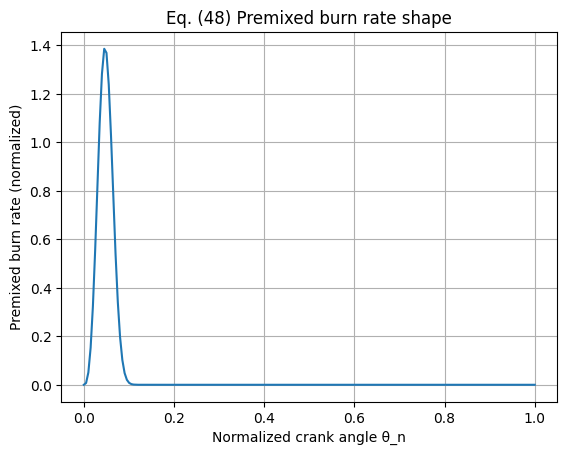

In [8]:
# Test 3: Premixed burn rate shape
theta_norm = np.linspace(0, 1, 200)
ID_test = 5.0   # crank-angle equivalent
RPM_test = 500

m_fpre = [premixed_burning_rate(tn, ID_test, RPM_test) for tn in theta_norm]

plt.plot(theta_norm, m_fpre)
plt.xlabel("Normalized crank angle θ_n")
plt.ylabel("Premixed burn rate (normalized)")
plt.title("Eq. (48) Premixed burn rate shape")
plt.grid(True)
plt.show()

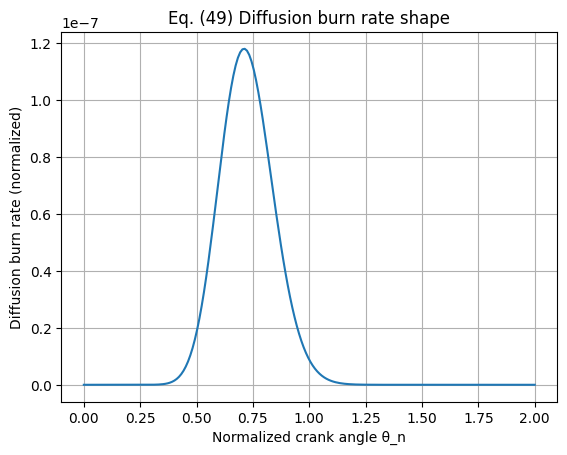

In [9]:
# Test 4: Diffusion burn rate shape
theta_norm = np.linspace(0, 2, 200)
F_test = 0.5   # equivalence ratio

m_fdiff = [diffusion_burning_rate(tn, F_test) for tn in theta_norm]

plt.plot(theta_norm, m_fdiff)
plt.xlabel("Normalized crank angle θ_n")
plt.ylabel("Diffusion burn rate (normalized)")
plt.title("Eq. (49) Diffusion burn rate shape")
plt.grid(True)
plt.show()

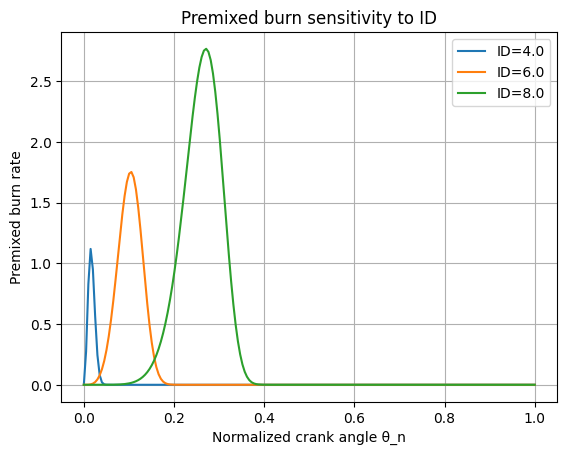

In [10]:
# Test 5: Premixed burn rate sensitivity to ID
theta_norm = np.linspace(0, 1, 200)
RPM_test = 500

IDs = [4.0, 6.0, 8.0] 

for ID in IDs:
    m = [premixed_burning_rate(tn, ID, RPM_test) for tn in theta_norm]
    plt.plot(theta_norm, m, label=f"ID={ID}")

plt.xlabel("Normalized crank angle θ_n")
plt.ylabel("Premixed burn rate")
plt.title("Premixed burn sensitivity to ID")
plt.legend()
plt.grid(True)
plt.show()


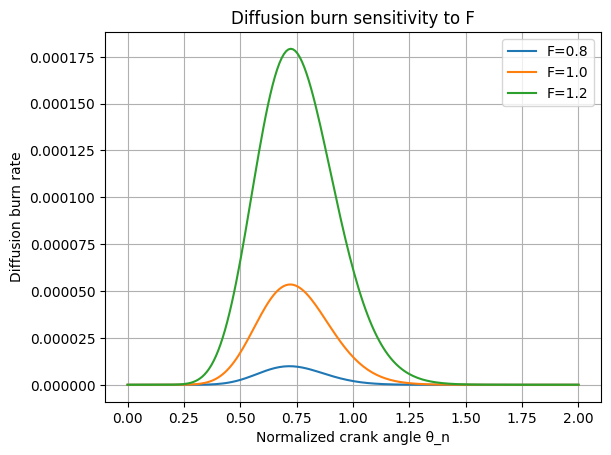

In [11]:
# Test 6: Diffusion burn rate sensitivity to equivalence ratio (F)
theta_norm = np.linspace(0, 2, 200)

Fs = [0.8, 1.0, 1.2]

for F in Fs:
    m = [diffusion_burning_rate(tn, F) for tn in theta_norm]
    plt.plot(theta_norm, m, label=f"F={F}")

plt.xlabel("Normalized crank angle θ_n")
plt.ylabel("Diffusion burn rate")
plt.title("Diffusion burn sensitivity to F")
plt.legend()
plt.grid(True)
plt.show()


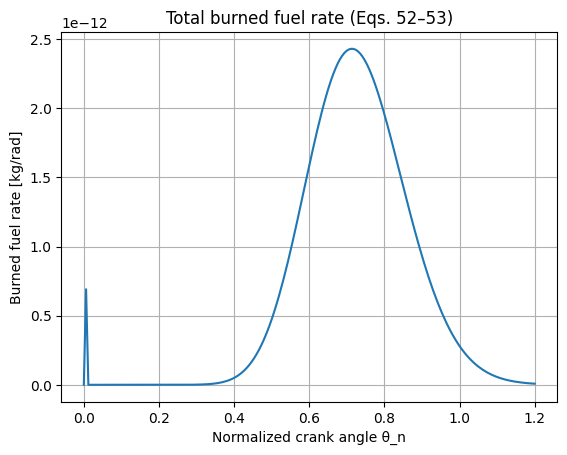

In [12]:
# Test 7: Combined burn rate
theta_norm = np.linspace(0, 1.2, 200)
ID_test = 1.5
F_test = 0.6
m_fuel = 1e-5 # kg
theta_comb = np.deg2rad(125)
RPM_test = 500

m_bf = []

for tn in theta_norm:
    m_fpre = premixed_burning_rate(tn, ID_test, RPM_test)
    m_fdiff = diffusion_burning_rate(tn, F_test)
    f_t = premixed_fraction(F_test, ID_test)
    m_bf.append(burned_fuel_rate(tn, f_t, m_fuel, theta_comb, m_fpre, m_fdiff))

plt.plot(theta_norm, m_bf)
plt.xlabel("Normalized crank angle θ_n")
plt.ylabel("Burned fuel rate [kg/rad]")
plt.title("Total burned fuel rate (Eqs. 52–53)")
plt.grid(True)
plt.show()


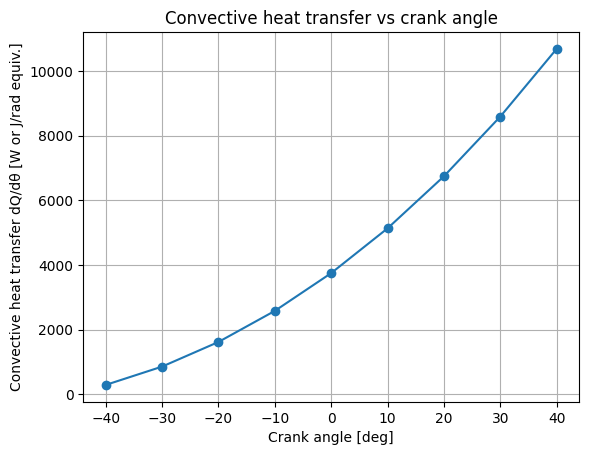

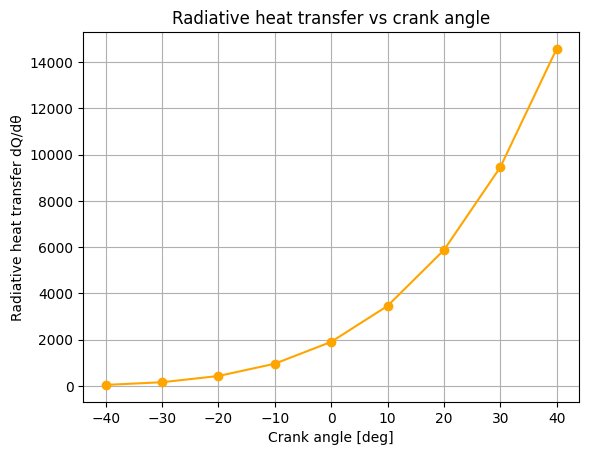

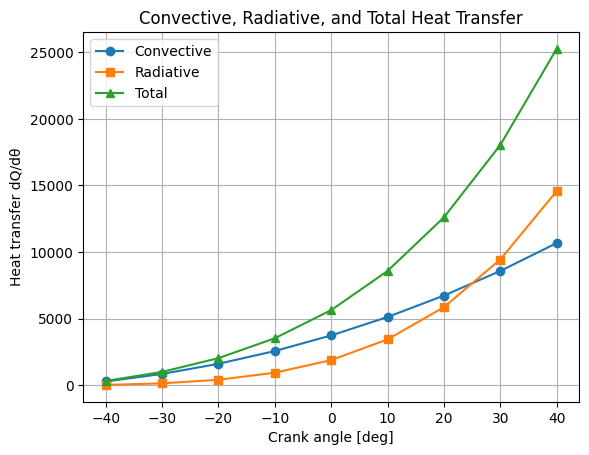

In [13]:
# Test 8: Heat transfer functions with synthetic data.

# Crank angle grid (just for labeling)
theta = np.linspace(-40, 40, 9)  # deg around TDC

# Synthetic in‑cylinder states
P = np.linspace(2e6, 8e6, len(theta))      # 2–8 MPa
T = np.linspace(600, 2200, len(theta))     # 600–2200 K
V = np.linspace(5e-5, 3e-5, len(theta))    # 50–30 cm³ (compression)
A = np.linspace(0.015, 0.025, len(theta))  # 0.015–0.025 m²
T_wall = 450.0                             # K, constant wall temp
stroke = 0.09                              # 90 mm
RPM = 1500

Qht_conv = [
    heat_transfer_convective(P[i], T[i], V[i], A[i], T_wall, stroke, RPM)
    for i in range(len(theta))
]

import matplotlib.pyplot as plt
plt.plot(theta, Qht_conv, marker="o")
plt.xlabel("Crank angle [deg]")
plt.ylabel("Convective heat transfer dQ/dθ [W or J/rad equiv.]")
plt.title("Convective heat transfer vs crank angle")
plt.grid(True)
plt.show()

T_rad = 1.1 * T  # if needed

Qht_rad = [
    heat_transfer_radiation(T_rad[i], T_wall, A[i])
    for i in range(len(theta))
]

plt.plot(theta, Qht_rad, marker="o", color="orange")
plt.xlabel("Crank angle [deg]")
plt.ylabel("Radiative heat transfer dQ/dθ")
plt.title("Radiative heat transfer vs crank angle")
plt.grid(True)
plt.show()


Qht_tot = np.array(Qht_conv) + np.array(Qht_rad)

plt.plot(theta, Qht_conv, marker="o", label="Convective")
plt.plot(theta, Qht_rad, marker="s", label="Radiative")
plt.plot(theta, Qht_tot, marker="^", label="Total")

plt.xlabel("Crank angle [deg]")
plt.ylabel("Heat transfer dQ/dθ")
plt.title("Convective, Radiative, and Total Heat Transfer")
plt.legend()
plt.grid(True)
plt.show()